In [ ]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import hashlib


from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

from utils import set_seed, LABEL_MAP, visualize_augmentations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

print(os.listdir('/content/drive/MyDrive/Cassava_Project'))

['cassava_data', 'cassava-leaf-disease-classification.zip', 'plots', 'models', 'dinov2_vitb14_best.pth', 'ֆայլեր', 'train_split.csv', 'val_split.csv', 'ProjecttCassava.ipynb', 'EDA.ipynb']


In [ ]:
set_seed(42)

In [ ]:
# Փոխարինիր քո ֆայլի ճանապարհով (path)
file_path = '/content/drive/MyDrive/Cassava_Project/cassava_data/train.csv'
df = pd.read_csv(file_path)

print(df.head())

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3


In [ ]:
print(len(df))
print(df.head())
print(df.describe())

21397
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3
              label
count  21397.000000
mean       2.651914
std        0.988565
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000


In [ ]:
print(" General Information ")
df.info()

 General Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


In [ ]:
print("\n 2. MISSING VALUES  ")
missing_data = df.isnull().sum()
print(missing_data)


 2. MISSING VALUES  
image_id    0
label       0
dtype: int64


0: Cassava Bacterial Blight (CBB)

1: Cassava Brown Streak Disease (CBSD)

2: Cassava Green Mottle (CGM)

3: Cassava Mosaic Disease (CMD)

4: Healthy

In [ ]:
unique_labels = sorted(df['label'].unique())
print("Unique labels in dataset:", unique_labels)

Unique labels in dataset: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Unique classes-ի քանակը

In [ ]:
num_classes = df['label'].nunique()
print("Number of unique classes:", num_classes)

Number of unique classes: 5


Գտնում ենք բոլոր այն արժեքները, որոնք 0-4 range-ից դուրս են

In [ ]:
expected_set = {0, 1, 2, 3, 4}
invalid_rows = df[~df['label'].isin(expected_set)]
print(f"Invalid label rows count: {len(invalid_rows)}")

Invalid label rows count: 0


In [ ]:
df_viz = df.copy()

label_map = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mottle (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy"
}

#  Ավելացնում ենք հիվանդության անվան սյունյակը copy-ի մեջ
df_viz['disease_name'] = df_viz['label'].map(label_map)

df_viz

,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy


Յուրքանչյուր տեսակից քանի նկար կա

In [ ]:
class_counts = df_viz['disease_name'].value_counts()
print(class_counts)

disease_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64


Նույնը տոկոսային հարաբերությամբ

In [ ]:
class_percentages = (df_viz['disease_name'].value_counts(normalize=True).sort_index() * 100).round(2)

print("Class Percentages")
print(class_percentages)

Class Percentages
disease_name
Cassava Bacterial Blight (CBB)          5.08
Cassava Brown Streak Disease (CBSD)    10.23
Cassava Green Mottle (CGM)             11.15
Cassava Mosaic Disease (CMD)           61.49
Healthy                                12.04
Name: proportion, dtype: float64


In [ ]:
import os
# Ստեղծում ենք EDA գրաֆիկների թղթապանակը Drive-ում
plots_dir = '/content/drive/MyDrive/Cassava_Project/plots'
os.makedirs(plots_dir, exist_ok=True)

Կառուցենք  Bar Chart

/tmp/ipykernel_3067/3249849199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


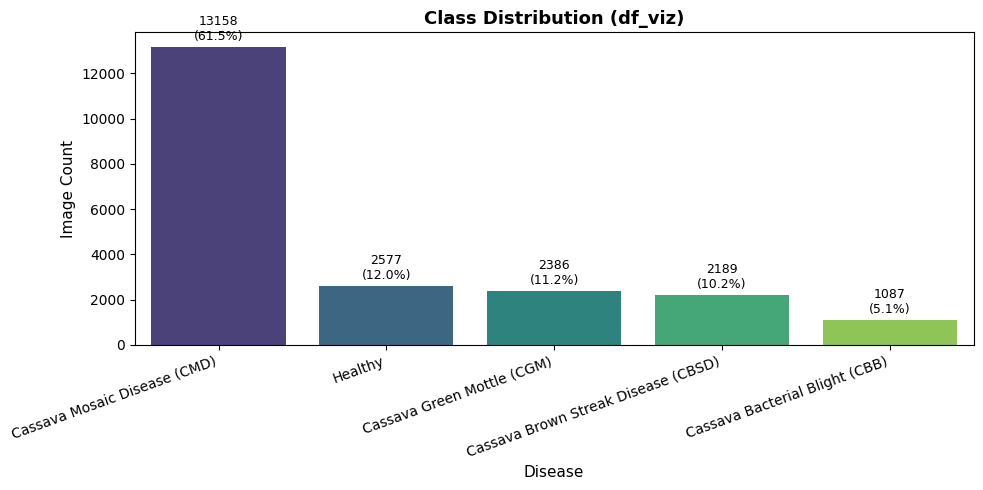

In [ ]:
chart_data = df_viz['disease_name'].value_counts().reset_index()
chart_data.columns = ['disease_name', 'count']
chart_data['percentage'] = (chart_data['count'] / len(df_viz) * 100).round(2)

# 2. Կառուցում ենք գրաֆիկը
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=chart_data,
    x='disease_name',
    y='count',
    palette='viridis'
)

plt.title('Class Distribution (df_viz)', fontsize=13, fontweight='bold')
plt.xlabel('Disease', fontsize=11)
plt.ylabel('Image Count', fontsize=11)
plt.xticks(rotation=20, ha='right')

# 3. Ավելացնում ենք քանակն ու տոկոսը սյուների վրա
for p in ax.patches:
    height = int(p.get_height())
    pct = (height / len(df_viz) * 100)
    ax.annotate(
        f'{height}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=9, xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/class_distribution.png', dpi=300, bbox_inches='tight'
)
plt.show()

In [ ]:
#Գտնենք ամենամեծ class-ը
max_class_name = class_counts.idxmax()
max_class_count = class_counts.max()
max_class_pct = (max_class_count / len(df_viz)) * 100

# 2. Գտնենք ամենափոքր class-ը
min_class_name = class_counts.idxmin()
min_class_count = class_counts.min()
min_class_pct = (min_class_count / len(df_viz)) * 100

# 3. Համեմատենք class-երի չափերը (Imbalance Ratio)
imbalance_ratio = max_class_count / min_class_count

print(f" Ամենամեծ class:  {max_class_name} -> {max_class_count:,} պատկեր ({max_class_pct:.2f}%)")
print(f" Ամենափոքր class: {min_class_name} -> {min_class_count:,} պատկեր ({min_class_pct:.2f}%)")
print(f" Imbalance ratio (Max / Min): {imbalance_ratio:.2f}x")

 Ամենամեծ class:  Cassava Mosaic Disease (CMD) -> 13,158 պատկեր (61.49%)
 Ամենափոքր class: Cassava Bacterial Blight (CBB) -> 1,087 պատկեր (5.08%)
 Imbalance ratio (Max / Min): 12.10x


Խիստ անհամաչափություն (Class Imbalance):
Ամենամեծ դասը (CMD) ~12.1 անգամ ավելի մեծ է, քան ամենափոքր դասը (CBB)։

Dominant Class:
Ամբողջ դատասեթի պատկերների ավելի քան 61%-ը պատկանում է ընդամենը 1 դասի (CMD)։

Եթե մոդելը սովորական ձևով թրեյն անենք, այն կարող է բիասավորվել (biased) դեպի CMD-ն և վատ ճանաչել CBB-ն կամ մյուս հազվադեպ դասերը։ Սա նշանակում է, որ հետագայում պետք կգա․

Stratified K-Fold (որպեսզի ամեն fold-ում դասերի հարաբերակցությունը պահպանվի)

Weighted Loss Function կամ Class Weights

Հատուկ Augmentation տեխնիկաներ փոքր դասերի համա

**Դիտարկենք յուրաքանչյուր class-ից sample-ներ**

In [ ]:
# Define Drive path
BASE_DIR = '/content/drive/MyDrive/Cassava_Project/cassava_data'

print("Ընթացիկ թղթապանակի ֆայլերը:")
print(os.listdir(BASE_DIR))

if os.path.exists(f'{BASE_DIR}/train_images'):
  IMAGES_DIR = f'{BASE_DIR}/train_images'
else:
  IMAGES_DIR = BASE_DIR

print(f"Օգտագործվող path: {IMAGES_DIR}")

Ընթացիկ թղթապանակի ֆայլերը:
['label_num_to_disease_map.json', 'sample_submission.csv', 'train.csv', 'test_images', 'test_tfrecords', 'train_tfrecords', 'train_images', 'cassava_data']
Օգտագործվող path: /content/drive/MyDrive/Cassava_Project/cassava_data/train_images


In [ ]:
if not os.path.exists(IMAGES_DIR):
    print(f" Թղթապանակը չի գտնվել: {IMAGES_DIR}")
    print("Խնդրում եմ ստուգել ճիշտ path-ը os.listdir()-ով:")


samples_per_class = 3
fig, axes = plt.subplots(5, samples_per_class, figsize=(15, 15))

for label in range(5):
    class_df = df_viz[df_viz['label'] == label].sample(samples_per_class)
    disease_title = class_df['disease_name'].iloc[0]

    for i, (_, row) in enumerate(class_df.iterrows()):
        img_path = os.path.join(IMAGES_DIR, row['image_id'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[label, i]
        ax.imshow(img)
        ax.axis('off')
        if i == 1:
            ax.set_title(f"Class {label}: {disease_title}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/sample_images_per_class.png', dpi=300, bbox_inches='tight'
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

CBB (Class 0): Տերևների վրա առկա են մուգ շագանակագույն, չորացած անկյունաձև բծեր (water-soaked lesions) և եզրերի այրված/չորացած տեսք։

CBSD (Class 1): Դեղնավուն և շագանակագույն նախշերը տարածված են հիմնականում տերևի ջղերի (veins) երկայնքով։

CGM (Class 2): Տերևի մակերեսին նկատվում են մանր, սպեկտրալ դեղնավուն/բաց-կանաչավուն կետեր ու բծեր (mottling)։

CMD (Class 3): Տերևները խիստ ծռմռված են, կնճռոտված և ասիմետրիկ՝ դեղնականաչավուն խճանկարային pattern-ով։

Healthy (Class 4): Տերևները հիմնականում հարթ են և առողջ կանաչ, սակայն առկա է Label Noise (որոշ նկարներում տեսանելի են հիվանդության բծեր կամ արտաքին վնասվածքներ)։

Նմանություններ և Ռիսկեր: CBB-ն և CBSD-ն տեսողականորեն բավականին նման են (շագանակագույն բծեր/դեղնում), ինչը կարող է առաջացնել misclassification: Background-ները և լուսավորվածությունը խիստ փոփոխական են։

Վերջին շարքի որևէ( քանի որ անընդհատ փոփոխվում է) նկարում ակնհայտ երևում են չորացած, շագանակագույն բծեր, որոնք CBB-ի կամ CBSD-ի ախտանիշ են, բայց դատասեթում այն նշված է որպես Class 4 (Healthy)։

Cassava Leaf Disease դատասեթի ամենահայտնի խնդիրներից մեկն է՝ Label Noise (սխալ/աղմկոտ լեյբլավորում)։

Մոդելը չի կարող հասնել 100% Accuracy-ի․ Քանի որ ground truth (ճիշտ պատասխան համարվող) տվյալների մեջ սխալներ կան, նույնիսկ կատարյալ մոդելը Kaggle-ում ~89-90% accuracy-ից վերև դժվար է բարձրանում։

Label Smoothing Loss․ Սովորական Cross-Entropy Loss-ի փոխարեն շատ օգտակար է օգտագործել Label Smoothing (օրինակ՝ smoothing=0.1)։ Սա թույլ է տալիս, որ մոդելը 100% վստահությամբ չհավատա սխալ լեյբլին և պատժվի ավելի քիչ, երբ տվյալներում աղմուկ (noise) կա։

Symmetric Cross Entropy (SCE) կամ Bi-Tempered Loss․ Այս հատուկ Loss function-ները նախագծված են հենց այսպիսի աղմկոտ (noisy) դատասեթերի դեմ պայքարելու համար։

Background-ների տարբերությունը

Խիստ բազմազան են․ Նկարներում երևում են հող, այլ ոչ հիվանդ/առողջ բույսեր, չորացած ցողուններ, իսկ որոշ sample-ներում նաև մարդու ձեռքեր կամ տերևը պահող մատներ։

Մոդելի ռիսկ․ Մոդելը կարող է պատահաբար սովորել background-ի դետալները (օրինակ՝ հողի գույնը) տերևի հիվանդության հետ կապելու փոխարեն։

Լուծում․ Պարտադիր է Random Resized Crop և Zoom augmentation-ների օգտագործումը, որպեսզի մոդելի ուշադրությունը կենտրոնանա միայն տերևի վրա։

Lighting-ի (լուսավորվածության) տարբերությունը

Խիստ փոփոխական է․ Կան պայծառ, ուղիղ արևի տակ արված նկարներ (որոնք տերևի վրա սպիտակ փայլեր/glare են առաջացնում), ինչպես նաև ստվերում կամ մռայլ եղանակին նկարված մութ կադրեր։

Մոդելի ռիսկ․ Արևի փայլերը մոդելը կարող է սխալմամբ ընդունել որպես CGM-ի դեղնավուն բծեր, իսկ մութ ստվերները՝ CBB-ի չորացած հատվածներ։

Լուծում․ ColorJitter, Brightness, and Contrast augmentation-ների կիրառումը թրեյնինգի ընթացքում։

In [ ]:
image_shapes = []
formats = set()

# Անցնում ենք բոլոր նկարների վրայով և հավաքում տվյալները
sample_df = df_viz.sample(1000, random_state=42)
for img_name in sample_df['image_id']:
    img_path = os.path.join(IMAGES_DIR, img_name)
    with Image.open(img_path) as img:
        width, height = img.size
        # Get channels (e.g. RGB -> 3)
        channels = len(img.getbands())
        formats.add(img.format)
        image_shapes.append((width, height, channels))

# Դարձնում ենք DataFrame վերլուծության համար
shapes_df = pd.DataFrame(image_shapes, columns=['width', 'height', 'channels'])

print("Image Dimensions & Channels")
print(shapes_df.describe())
print(f"\nUnique Formats: {formats}")
print(f"Unique Channels: {shapes_df['channels'].unique()}")

Image Dimensions & Channels
        width  height  channels
count  1000.0  1000.0    1000.0
mean    800.0   600.0       3.0
std       0.0     0.0       0.0
min     800.0   600.0       3.0
25%     800.0   600.0       3.0
50%     800.0   600.0       3.0
75%     800.0   600.0       3.0
max     800.0   600.0       3.0

Unique Formats: {'JPEG'}
Unique Channels: [3]


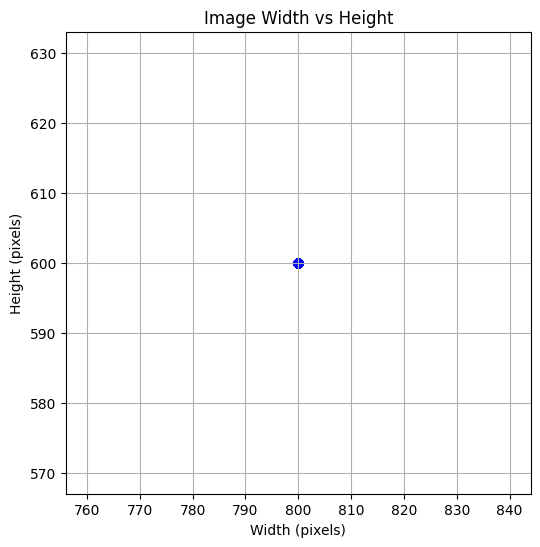

In [ ]:
widths, heights = [], []

# Օգտագործում ենք ավելի վաղ ստացված shapes_df-ը կամ նորից կարդում sample
sample_df = df_viz.sample(1000, random_state=42)
for img_name in sample_df['image_id']:
    img_path = os.path.join(IMAGES_DIR, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.5, c='blue')
plt.title("Image Width vs Height")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True)
plt.show()

Սա վերջնականապես վստահեցնում է, որ preprocessing-ի ժամանակ բարդ aspect-ratio-preserving resize-ների (օրինակ՝ եզրերին սև գոտիներ / padding ավելացնելուն) կարիք չկա։ Կարող ենք ուղիղ resize անել քառակուսի (օրինակ՝ 256x256)։

Արդյունքները

Width & Height: Բոլոր պատկերները standard 800 x 600 resolution ունեն (800px width, 600px height)։

Minimum Dimensions: 800 x 600

Maximum Dimensions: 800 x 600

Channels: 3 (RGB color channels)

Image Format: JPEG (.jpg)

Key Takeaway Modeling-ի համար.
Դատասեթը չափսերի առումով լիովին uniform (միատարր) է՝ չկան տարբեր չափսերի կամ corrupted format-ով նկարներ։ Այնուամենայնիվ, թրեյնինգի ժամանակ բոլորը resize կանենք (օրինակ՝ 224x224, 384x384 կամ 512x512), որպեսզի GPU-ն ավելի արագ մշակի։

In [ ]:
# 1. Missing / Invalid labels & Duplicate rows
missing_labels = df['label'].isnull().sum()
invalid_labels = (~df['label'].isin(range(5))).sum()
duplicate_rows = df.duplicated().sum()

# 2. Missing files, Corrupted images, Formats & Image Hashing for Duplicates
missing_files = 0
corrupted_images = 0
unexpected_formats = []
image_hashes = set()
duplicate_images_count = 0

for img_name in df['image_id']:
    img_path = os.path.join(IMAGES_DIR, img_name)

    # Check if file exists
    if not os.path.exists(img_path):
        missing_files += 1
        continue

    try:
        with Image.open(img_path) as img:
            img.verify() # Corrupted image check

        # Format check
        if not img_name.lower().endswith(('.jpg', '.jpeg')):
            unexpected_formats.append(img_name)

        # Duplicate images check via MD5 Hash
        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash in image_hashes:
                duplicate_images_count += 1
            else:
                image_hashes.add(file_hash)

    except Exception:
        corrupted_images += 1

print("=== Data Quality & Integrity Report ===")
print(f" Missing labels: {missing_labels}")
print(f" Invalid labels (not 0-4): {invalid_labels}")
print(f" Duplicate DataFrame rows: {duplicate_rows}")
print(f" Missing image files: {missing_files}")
print(f" Corrupted images: {corrupted_images}")
print(f" Duplicate images (exact file match): {duplicate_images_count}")
print(f" Unexpected file formats: {len(unexpected_formats)}")

Դատասեթը տեխնիկական առումով շատ մաքուր է (ֆայլերը ամբողջական են, չկան corrupted կամ չբացվող նկարներ): Միակ հիմնական խնդիրները, որոնց դեմ պետք է պայքարենք մոդելավորման ժամանակ, նախորդ քայլերում գտած Class Imbalance-ը և Label Noise-ն են

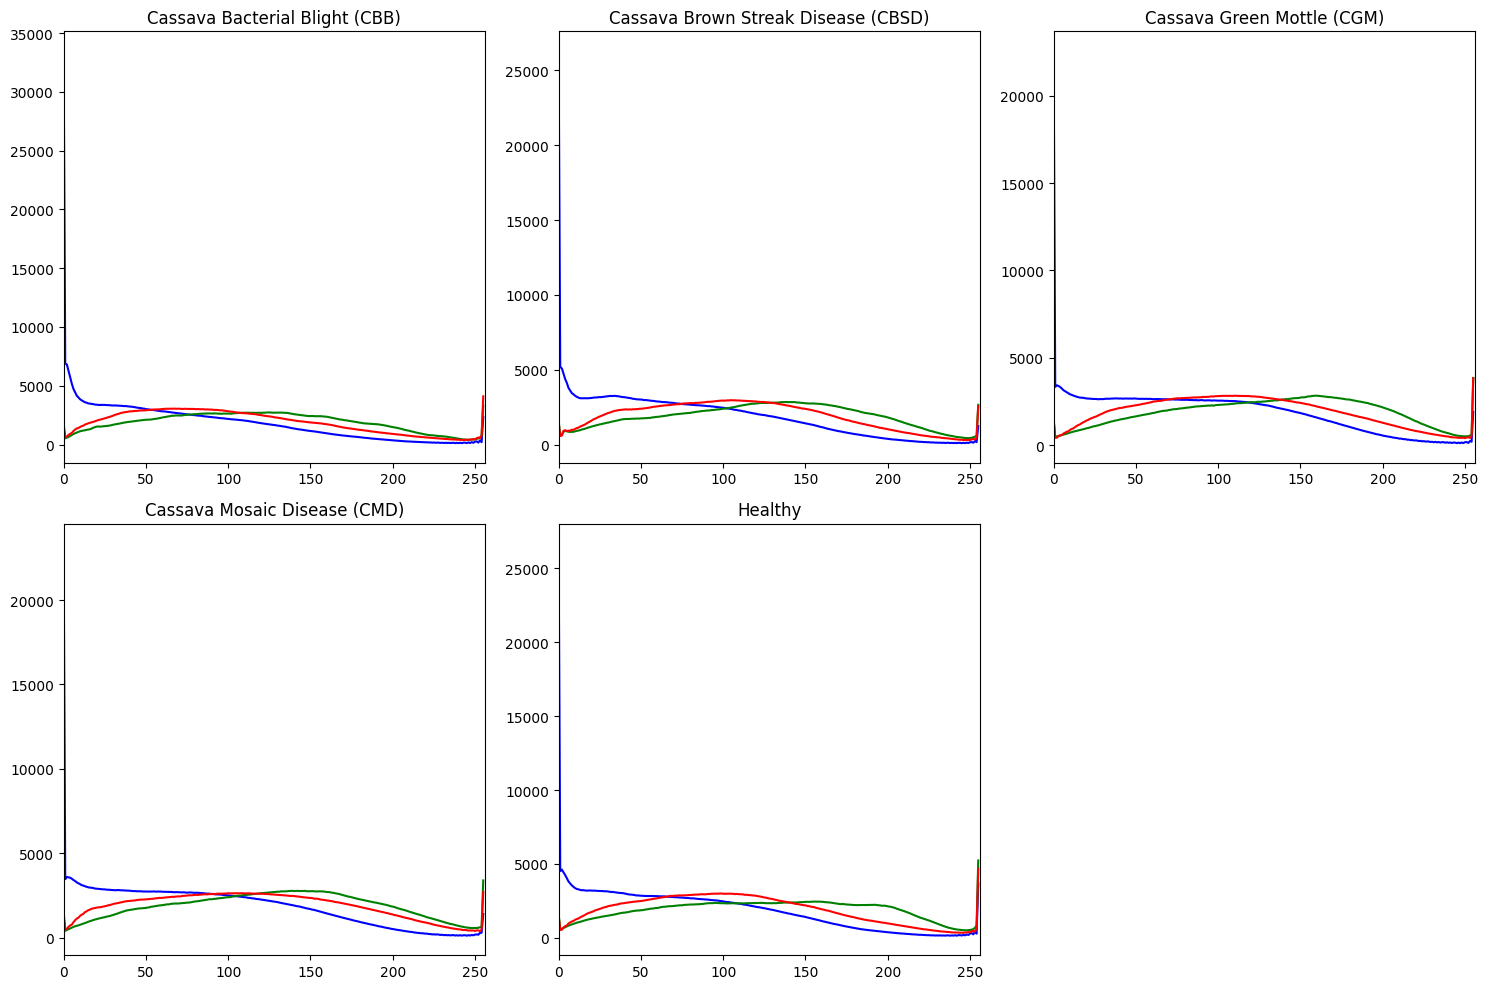

In [ ]:
colors = ('b', 'g', 'r')
plt.figure(figsize=(15, 10))

for label in range(5):
    class_sample = df_viz[df_viz['label'] == label].sample(100, random_state=42)
    disease_name = class_sample['disease_name'].iloc[0]

    mean_hist = {c: np.zeros((256, 1)) for c in colors}

    for img_name in class_sample['image_id']:
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = cv2.imread(img_path)
        for i, col in enumerate(colors):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            mean_hist[col] += hist / 100

    plt.subplot(2, 3, label + 1)
    for col in colors:
        plt.plot(mean_hist[col], color=col)
    plt.title(disease_name)
    plt.xlim([0, 256])

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/color_histograms_per_class.png', dpi=300, bbox_inches='tight'
)
plt.show()

Blue Channel Spike (մուգ կապույտ պիկը 0-ի վրա)․
Բոլոր դասերի մոտ 0-ական ինտենսիվության վրա կա շատ բարձր Blue (B) պիկ։ Սա ցույց է տալիս, որ նկարներում Blue channel-ի ցածր արժեքները (գրեթե 0) շատ են, ինչը բնական է կանաչ տերևների և մուգ/ստվերոտ ֆոնի համար (RGB համակարգում կանաչն ու դեղինը ունեն շատ ցածր Blue ինտենսիվություն)։

Green vs Red channels (Կանաչի և Կարմիրի հարաբերակցությունը)․

Healthy (Առողջ)․ Կանաչ (Green) կորը 150-200 տիրույթում ակնհայտ բարձր է Կարմիրից (Red)։ Սա մաթեմատիկորեն հաստատում է առողջ, հագեցած կանաչ տերևների առկայությունը։

CBB & CBSD (Հիվանդություններ)․ Կանաչի և Կարմիրի կորերը շատ մոտ են իրար, իսկ որոշ հատվածներում Կարմիրը բարձրանում է։ Սա չորացած, շագանակագույն ու դեղնած հատվածների (Green-ի նվազման և Red-ի բարձրացման) ուղղակի հետևանքն է։

CGM & CMD․ Ունեն բավականին հավասարաչափ բաշխում, քանի որ տերևների վրա կան թե՛ կանաչ, թե՛ դեղնավուն (Mosaic/Mottle) հատվածներ։

Color Augmentations-ի սահմանափակում․
Hue (գույնի երանգ) augmentation-ը պետք է կիրառել շատ զգույշ կամ շատ փոքր range-ով (օրինակ՝ hue_shift_limit=5): Եթե գույները շատ փոխենք, կանաչ տերևը կարող է դառնալ դեղնավուն, և մոդելը Healthy-ն կշփոթի CGM-ի կամ CBSD-ի հետ։

Brightness / Contrast Augmentation-ի անհրաժեշտություն․
Քանի որ 0-250 տիրույթում ինտենսիվությունները լայն տարածված են (լուսավորության խիստ տատանումների պատճառով), Brightness/Contrast փոփոխությունները կօգնեն մոդելին անկախ լինել լուսավորությունից։

Normalization Constants (ImageNet standards)․
Թրեյնինգի ժամանակ ImageNet-ի standard mean/std-ով normalize անելը (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) լիովին արդարացված է, քանի որ RGB ալիքների բաշխվածությունը բնական լուսանկարների standard կառուցվածք ունի։

In [ ]:
plt.figure(figsize=(15, 6))

for label in range(5):
    class_sample = df_viz[df_viz['label'] == label].sample(100, random_state=42)
    disease_name = class_sample['disease_name'].iloc[0]

    # Նախապես ստեղծում ենք զրոյական մատրիցա
    mean_img = np.zeros((600, 800, 3), dtype=np.float32)

    for img_name in class_sample['image_id']:
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_img += img / 100

    mean_img = np.uint8(mean_img)

    plt.subplot(1, 5, label + 1)
    plt.imshow(mean_img)
    plt.title(f"Class {label}")
    plt.axis('off')

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/mean_images.png', dpi=300, bbox_inches='tight'
)
plt.show()

Կենտրոնացված լուսավորություն/դեղնություն (Class 0 & Class 1)՝
Class 0-ի (CBB) և Class 1-ի (CBSD) միջինացված պատկերներում կենտրոնում ակնհայտ երևում է ավելի վառ, դեղնավուն/բաց-կանաչ կլորավուն տիրույթ։ Սա հաստատում է, որ այս հիվանդությունների դեպքում ֆոտոգրաֆները/ֆերմերները նկարելիս կադրի կենտրոնը ուղղել են հենց վնասված, դեղնած տերևի վրա։

Լղոզված և միատարր ֆոն (Class 2, 3, 4)՝
Class 2-ի, 3-ի և 4-ի (Healthy) մոտ պատկերը շատ ավելի միատարր կանաչ-մոխրագույն է։ Սա նշանակում է, որ այս դասերում տերևների դիրքավորումն ու չափսերը կադրում ավելի պատահական են բաշխված։

Ոչ մի class-ի մոտ չկա հստակ «տերևի տեսք» (edges): Սա ցույց է տալիս, որ դատասեթում տերևների անկյունները (orientations), մասշտաբները (scales) և background-ները խիստ բազմազան են։

Spatial/Position Invariance-ի կարիք՝
Քանի որ հիվանդությունները միայն կենտրոնում չեն, մոդելը չպետք է «կախվածություն» ձեռք բերի նկարի կենտրոնական հատվածից։

Անհրաժեշտ Augmentation-ներ՝

Random Horizontal & Vertical Flips: Օգնում է, որ մոդելը սովորի pattern-ները անկախ տերևի ուղղությունից։

ShiftScaleRotate / Random Crop: Ստիպում է մոդելին գտնել ախտանիշները, նույնիսկ եթե տերևը կադրի անկյունում է կամ խոշոր պլանով (zoom):